# Random Forest Hyperparameter Tuning

## Notebook Objective

This notebook tunes a Random Forest Regressor for monthly cost prediction using cross-validation.

The goal is to test whether hyperparameter tuning improves Random Forest performance compared with the baseline Random Forest model from the previous notebook.

The tuned model is evaluated on a held-out test set using MAE, RMSE, and R².

This notebook focuses on model tuning and generalization, not causal interpretation.

## 1. Imports

In [1]:
import pandas as pd # Load and manipulate tabular data
import numpy as np # Numerical calculations

import matplotlib.pyplot as plt # Create plots

from sklearn.model_selection import train_test_split, GridSearchCV # Split data and tune hyperparameters 
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and modeling steps

from sklearn.ensemble import RandomForestRegressor # Main Day 14 model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics

## 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load processed feature dataset

df.head() # Preview data

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define target and features

In [3]:
target = "monthly_cost" # Regression target

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns = drop_cols) # Create feature matrix
y = df[target] # Create target vector 

## Feature Selection Logic

This notebook uses the same cleaned cost-prediction feature set as the prior regression notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost` and would create target leakage.

Grouped variables such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included.

Derived utilization variables such as `total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` are excluded because `ed_visits` and `ip_admits` are already included separately.

This keeps the tuned Random Forest comparison consistent with the earlier cost-regression notebooks.

## 4. Detect column types

In [4]:
categorical_cols = X.select_dtypes(
    include = ["object", "string", "category", "bool"]
).columns.tolist() # Identify categorical variables

numeric_cols = X.select_dtypes(
    include = ["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'region', 'plan_type']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


## 5. Train/test split 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Feature Matrix
    y, # Target vector
    test_size = 0.20, # Reserve 20% for testing
    random_state = 42 # Reproducible split 
)

## 6. Build preprocessing

In [6]:
preprocessor = ColumnTransformer( 
    transformers = [
        (
                "cat",
                OneHotEncoder(handle_unknown = "ignore"),
                categorical_cols
        )
    ],
    remainder = "passthrough" # Keep numeric variables unchanged 
)

## 7. Build base Random Forest pipeline

In [7]:
rf_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Encode categorical variables
        (
            "model",
            RandomForestRegressor( 
                random_state=42, # Reproducible model
                n_jobs = -1 # Use all available CPU cores
            )
        )
    ]
)

## 8. Define hyperparameter grid 

In [8]:
param_grid = {
    "model__n_estimators" : [100, 200, 300], # Number of trees 
    "model__max_depth" : [5, 10, None], # Maximum tree depth
    "model__min_samples_leaf": [1, 5, 10], # Minimum samples in each leaf
    "model__max_features": ["sqrt", 1.0] # Number of features considered at each split 
}

## 9. Run GridSearchCV

In [9]:
grid_search = GridSearchCV(
    estimator = rf_pipeline, # Pipeline to tune 
    param_grid = param_grid, # Hyperparameter combinations
    scoring = "neg_root_mean_squared_error", # Use RMSE, but sklearn stores it as negative
    cv = 5, # 5-fold cross-validation
    n_jobs = -1, # Use all CPU cores
    verbose = 1  # Show progress 
)

grid_search.fit(X_train, y_train) # Run tuning on training data only

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 1.0], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

## 10. Review best parameters

In [10]:
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)


Best parameters:
{'model__max_depth': 10, 'model__max_features': 1.0, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best CV RMSE:
565.2222179389838


## 11. Evaluate tuned model on test set

In [11]:
best_rf_model = grid_search.best_estimator_ # Extract best pipeline 

y_train_pred = best_rf_model.predict(X_train) # Predict training set
y_test_pred = best_rf_model.predict(X_test) # Predict test set

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

tuned_rf_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2]

})

tuned_rf_results


,Dataset,MAE,RMSE,r2
0,Train,269.833171,430.411380,0.883201
1,Test,392.531781,668.571266,0.753415


## 12. Compare baseline vs tuned Random Forest

In [12]:
baseline_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

baseline_rf_pipeline.fit(X_train, y_train)

baseline_test_pred = baseline_rf_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_r2 = r2_score(y_test, baseline_test_pred)

In [13]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Test MAE": [
        baseline_mae,
        test_mae
    ],
    "Test RMSE": [
        baseline_rmse,
        test_rmse
    ],
    "Test R²": [
        baseline_r2,
        test_r2
    ]
})

rf_comparison

,Model,Test MAE,Test RMSE,Test R²
0,Baseline Random Forest,398.028933,671.461443,0.751278
1,Tuned Random Forest,392.531781,668.571266,0.753415


## Model Comparison Interpretation

The tuned Random Forest should be compared against the baseline Random Forest using the same train/test split and the same cleaned feature set.

If the tuned model has lower RMSE and higher R², the tuning improved test-set performance.

If the tuned model performs similarly or worse, that means the original baseline settings were already reasonable, the tuning grid was not useful, or the selected cross-validation objective did not translate into better test-set performance.

The practical size of the improvement matters more than whether one metric is slightly better by decimals.

## 13. Actual vs predicted plot

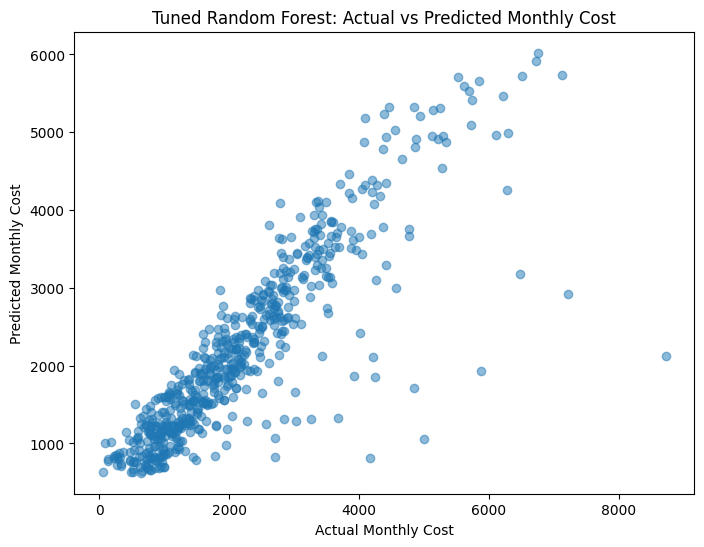

In [14]:
plt.figure(figsize = (8, 6))

plt.scatter(y_test, y_test_pred, alpha = 0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Tuned Random Forest: Actual vs Predicted Monthly Cost")

plt.show()

## 14. Residual plot

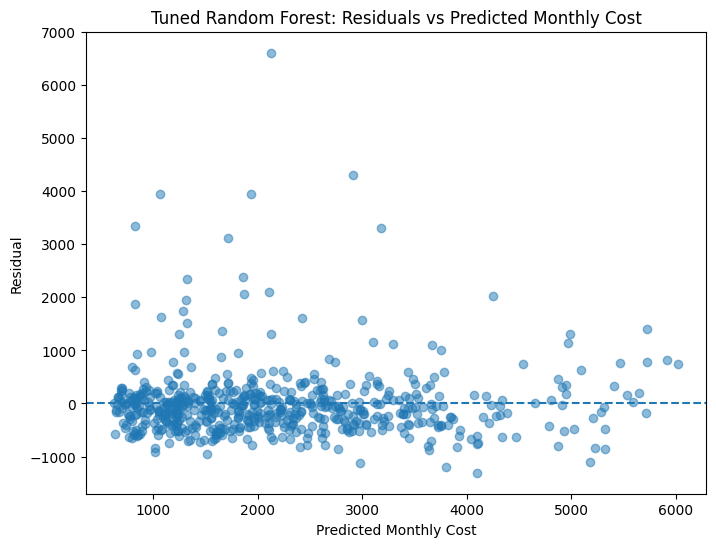

In [15]:
residuals = y_test - y_test_pred # Actual minus predicted

plt.figure(figsize = (8,6))

plt.scatter(y_test_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle = "--")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Tuned Random Forest: Residuals vs Predicted Monthly Cost")

plt.show()

## 15. Feature importance from tuned model

In [16]:
trained_preprocessor = best_rf_model.named_steps["preprocessor"] # Access fitted preprocessor
trained_rf = best_rf_model.named_steps["model"] # Access fitted tuned Random Forest

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_rf.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(20)

,feature,importance
10,remainder__chronic_condition_count,0.533792
15,remainder__ip_admits,0.298115
14,remainder__ed_visits,0.059256
11,remainder__engagement_score,0.026458
5,cat__plan_type_DSNP,0.022274
8,remainder__age,0.020882
9,remainder__sdoh_risk_score,0.018168
6,cat__plan_type_Medicaid,0.006296
13,remainder__prior_awv_rate,0.003660
12,remainder__pcp_attributed_24mo,0.003491


## 16. Plot top feature importances

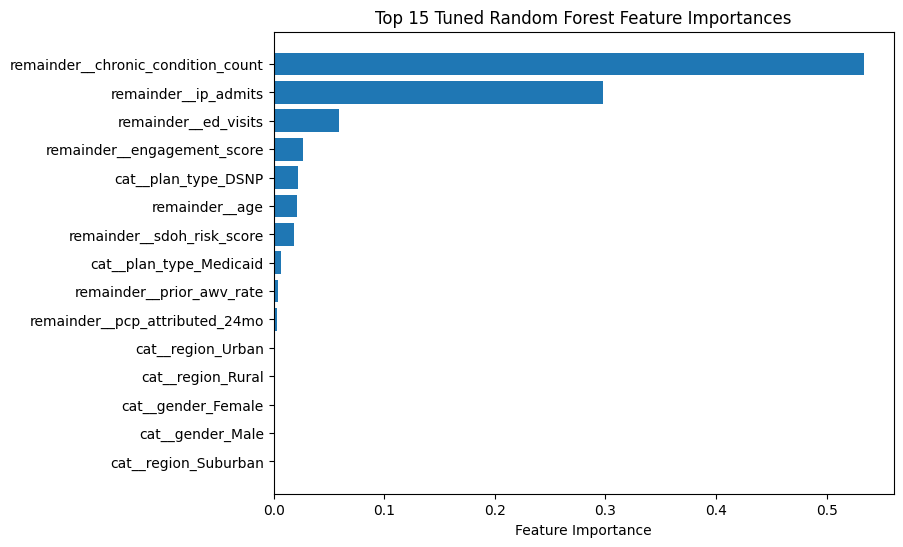

In [17]:
top_features = importance_df.head(15).sort_values(by="importance") # Sort for horizontal plot

plt.figure(figsize=(8, 6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Tuned Random Forest Feature Importances")

plt.show() 


## 17. Findings

This notebook tuned a Random Forest Regressor for monthly cost prediction using 5-fold cross-validation.

The model used the same cleaned feature set as the prior cost-regression notebooks to avoid leakage and maintain comparison consistency.

The tuning grid tested different values for number of trees, maximum tree depth, minimum samples per leaf, and maximum features considered at each split.

The best model was selected using cross-validated RMSE on the training data only.

Final performance was evaluated on the held-out test set using MAE, RMSE, and R².

In this run, the tuned Random Forest slightly improved over the baseline Random Forest. Test MAE decreased from about `$398` to `$393`, test RMSE decreased from about `$671` to `$669`, and R² increased from about `0.751` to `0.753`.

However, the improvement is small and probably not practically meaningful.

This suggests that hyperparameter tuning helped slightly, but the baseline Random Forest settings were already reasonably strong.

This suggests that the baseline Random Forest settings were already reasonable, or that the selected tuning grid did not produce a better generalizing model.

The tuned Random Forest also did not clearly outperform the tuned Ridge model from earlier notebooks, so Random Forest tuning did not become the strongest overall cost model in this project.

Feature importance showed that chronic condition count, inpatient admissions, and ED visits were the most important predictors in the fitted Random Forest model.

Feature importance values show predictive usefulness inside the fitted model. They do not prove causal effects.

Because this project uses synthetic data, these findings reflect the data-generation assumptions rather than real-world healthcare evidence.

A logical next step is to test Gradient Boosting Regression, which may capture nonlinear structure differently from Random Forest.